<a href="https://colab.research.google.com/github/ashleyholen/Data-Science-Capstone/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
#packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
#reading in data
energy = pd.read_csv("drive/MyDrive/DS_Capstone/try_this.csv")

In [118]:
#looking at first 5 rows
energy.head()

,description,units,source key,Jan-01,Feb-01,Mar-01,Apr-01,May-01,Jun-01,Jul-01,...,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25
0,all fuels (utility-scale),thousand megawatthours,ELEC.GEN.ALL-HI-99.M,925,801,873,836,886,874,936,...,836,758,808,762,667,749,751,737,769,811
1,coal,thousand megawatthours,ELEC.GEN.COW-HI-99.M,134,131,137,111,141,137,138,...,--,--,--,--,--,--,--,--,--,--
2,petroleum liquids,thousand megawatthours,ELEC.GEN.PEL-HI-99.M,726,613,691,653,669,660,725,...,651,584,644,591,513,540,541,505,553,578
3,petroleum coke,thousand megawatthours,ELEC.GEN.PC-HI-99.M,--,--,--,--,--,--,--,...,--,--,--,--,--,--,--,--,--,--
4,natural gas,thousand megawatthours,ELEC.GEN.NG-HI-99.M,0,0,0,0,0,0,0,...,--,--,--,--,--,--,--,--,--,--


In [119]:
# take out units and source key col first

cols_to_drop = ['units', 'source key']
energy = energy.drop(columns=cols_to_drop)

In [120]:
# melt from wide to long format
df_long = energy.melt(
    id_vars=["description"], # keep fuel type
    var_name="date_str", # new column for the old column names
    value_name="net_generation" # new column for values
)


In [121]:
df_long.head()

,description,date_str,net_generation
0,all fuels (utility-scale),Jan-01,925
1,coal,Jan-01,134
2,petroleum liquids,Jan-01,726
3,petroleum coke,Jan-01,--
4,natural gas,Jan-01,0


In [122]:
df_long.tail()


,description,date_str,net_generation
5600,hydro-electric pumped storage,Jul-25,--
5601,other,Jul-25,25
5602,all solar,Jul-25,264
5603,small-scale solar photovoltaic,Jul-25,160
5604,all utility-scale solar,Jul-25,104


In [123]:
df_long

,description,date_str,net_generation
0,all fuels (utility-scale),Jan-01,925
1,coal,Jan-01,134
2,petroleum liquids,Jan-01,726
3,petroleum coke,Jan-01,--
4,natural gas,Jan-01,0
...,...,...,...
5600,hydro-electric pumped storage,Jul-25,--
5601,other,Jul-25,25
5602,all solar,Jul-25,264
5603,small-scale solar photovoltaic,Jul-25,160


In [124]:
# replace '--' and 'NM' with NaN, convert to float
# i don't know what 'NM' stands for... "not metered"?
df_long["net_generation"] = (
    df_long["net_generation"]
    .replace({"--": pd.NA, "NM": pd.NA})
)

df_long["net_generation"] = pd.to_numeric(df_long["net_generation"], errors="coerce")

# convert date_str like "Jan-01" into a real datetime
df_long["date"] = pd.to_datetime(df_long["date_str"], format="%b-%y")
df_long["date"] = df_long["date"].dt.strftime("%b %Y")

# rename description as fuel_type and select final columns to keep
tidy_df = df_long.rename(columns={"description": "fuel_type"})[
    ["date", "fuel_type", "net_generation"]
]

In [125]:
tidy_df.head()

,date,fuel_type,net_generation
0,Jan 2001,all fuels (utility-scale),925.0
1,Jan 2001,coal,134.0
2,Jan 2001,petroleum liquids,726.0
3,Jan 2001,petroleum coke,NaN
4,Jan 2001,natural gas,0.0


In [126]:
tidy_df

,date,fuel_type,net_generation
0,Jan 2001,all fuels (utility-scale),925.0
1,Jan 2001,coal,134.0
2,Jan 2001,petroleum liquids,726.0
3,Jan 2001,petroleum coke,NaN
4,Jan 2001,natural gas,0.0
...,...,...,...
5600,Jul 2025,hydro-electric pumped storage,NaN
5601,Jul 2025,other,25.0
5602,Jul 2025,all solar,264.0
5603,Jul 2025,small-scale solar photovoltaic,160.0


In [127]:
#finding net gen totals since 2001 by fuel type

fuel_totals = (
    tidy_df.groupby("fuel_type", as_index=False)["net_generation"]
    .sum(numeric_only=True)
)

fuel_totals

,fuel_type,net_generation
0,all fuels (utility-scale),254822.0
1,all solar,16938.0
2,all utility-scale solar,8662.0
3,biomass,7178.0
4,coal,31448.0
5,conventional hydroelectric,2245.0
6,geothermal,4768.0
7,hydro-electric pumped storage,0.0
8,natural gas,0.0
9,nuclear,0.0


In [128]:
tidy_df["date"] = pd.to_datetime(tidy_df["date"])

/tmp/ipython-input-3106731659.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tidy_df["date"] = pd.to_datetime(tidy_df["date"])


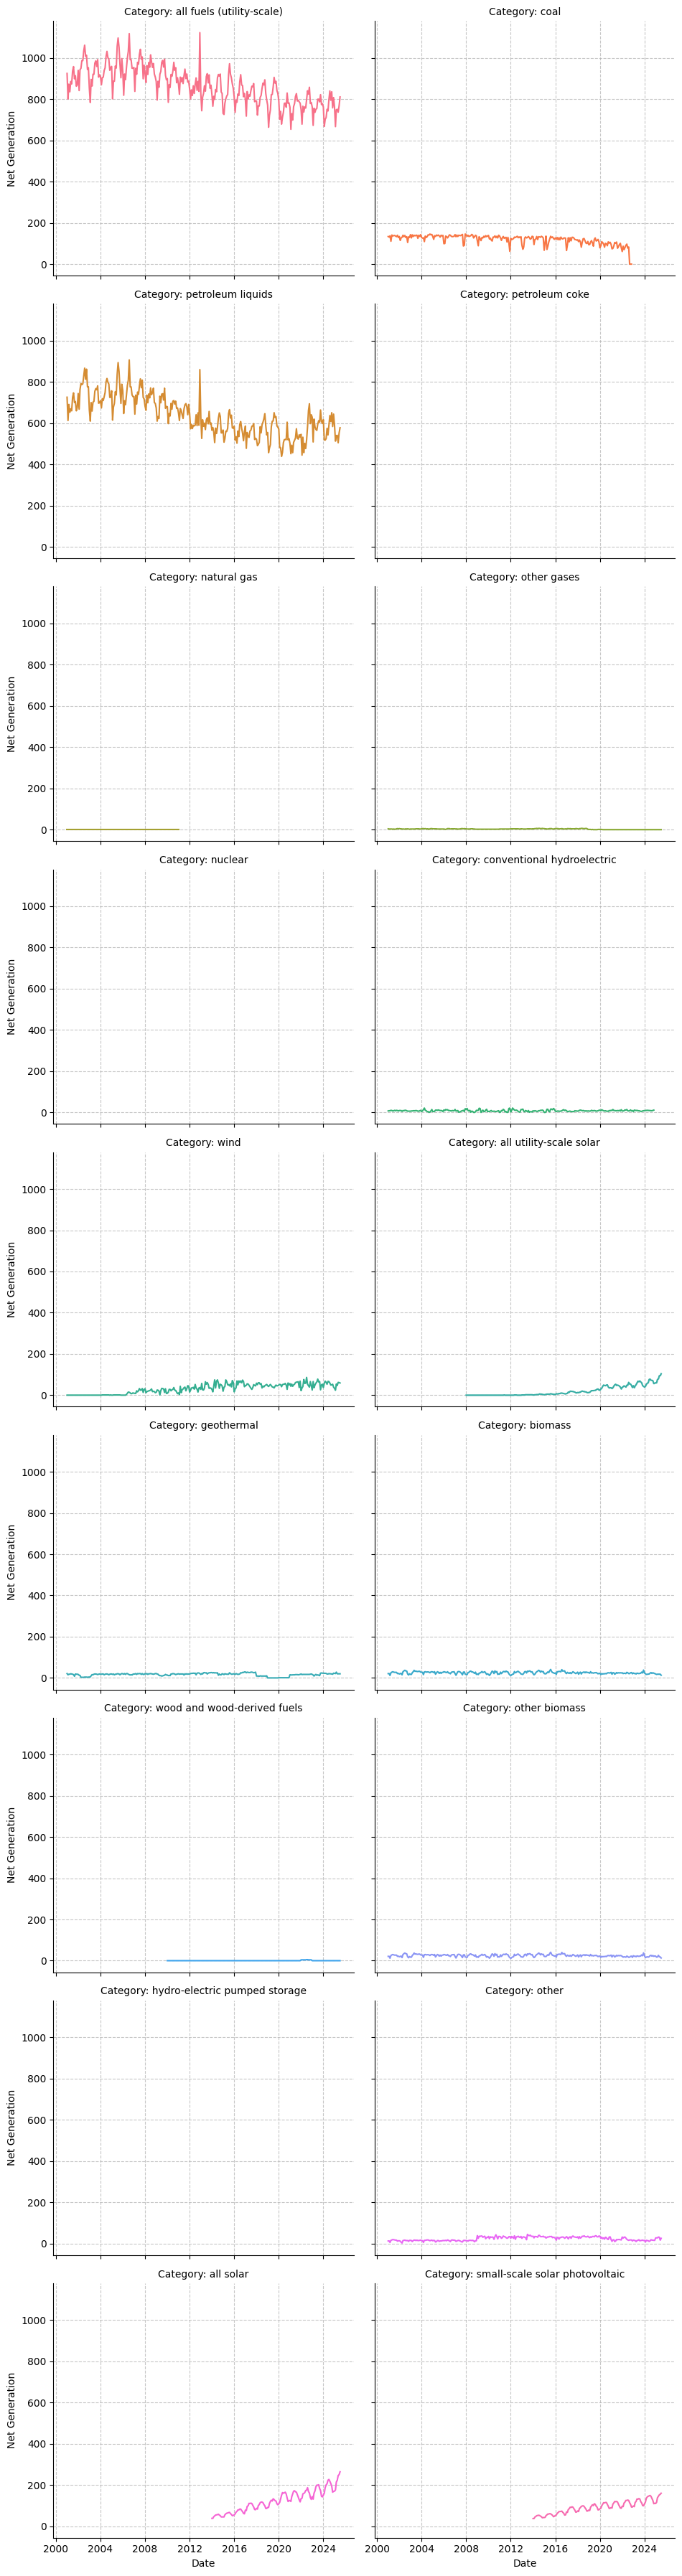

In [129]:
#facet grid
g = sns.FacetGrid(tidy_df, col="fuel_type", hue="fuel_type", col_wrap=2, height=4, aspect=1.2)

#lineplot for each facet
g.map(sns.lineplot, "date", "net_generation")

#axis labels
g.set_axis_labels("Date", "Net Generation")

#facet titles based on col name
g.set_titles(col_template="Category: {col_name}")

#adding gridlines to each subplot
for ax in g.axes.flat:
    ax.grid(True, which='major', linestyle='--', alpha=0.7)

#layout and show
plt.tight_layout()
plt.show()


In [130]:
tidy_df.head()

,date,fuel_type,net_generation
0,2001-01-01,all fuels (utility-scale),925.0
1,2001-01-01,coal,134.0
2,2001-01-01,petroleum liquids,726.0
3,2001-01-01,petroleum coke,NaN
4,2001-01-01,natural gas,0.0


In [131]:
tidy_df["year"] = tidy_df["date"].dt.year

#grouping by year and category, then sum net gen
yearly_sum = (
    tidy_df
    .groupby(["year", "fuel_type"], as_index=False)
    ["net_generation"].sum()
)

yearly_sum

,year,fuel_type,net_generation
0,2001,all fuels (utility-scale),10634.0
1,2001,all solar,0.0
2,2001,all utility-scale solar,0.0
3,2001,biomass,289.0
4,2001,coal,1606.0
...,...,...,...
445,2025,petroleum coke,0.0
446,2025,petroleum liquids,3821.0
447,2025,small-scale solar photovoltaic,976.0
448,2025,wind,340.0


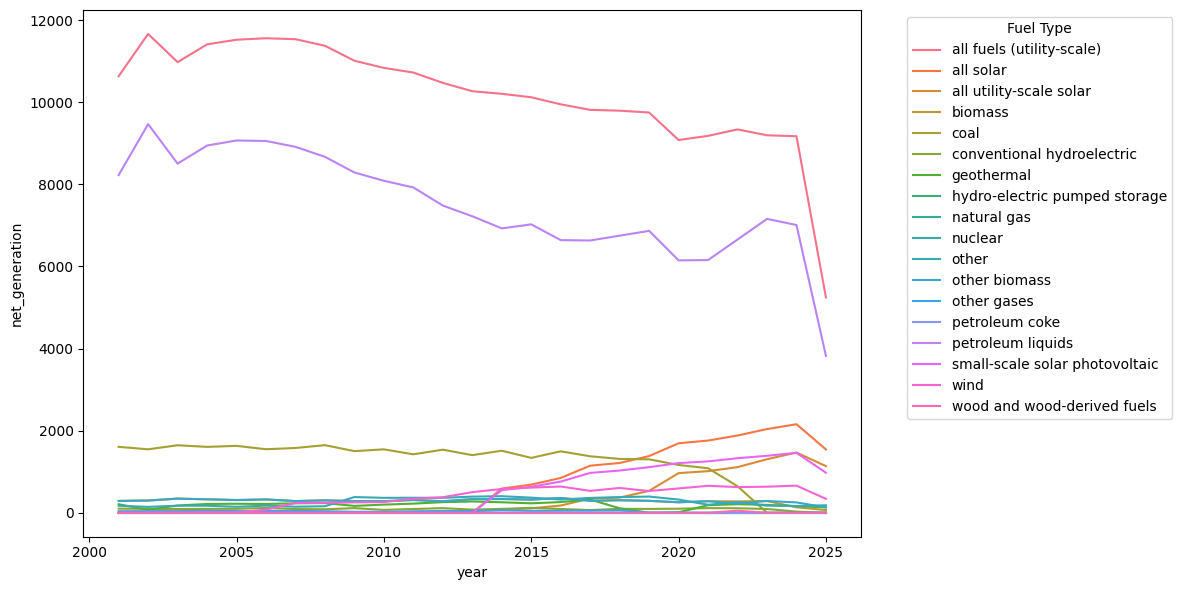

In [132]:
# Make the figure larger (width=12, height=6)
plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum, x="year", y="net_generation", hue = "fuel_type")

# Move the legend outside the plot
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

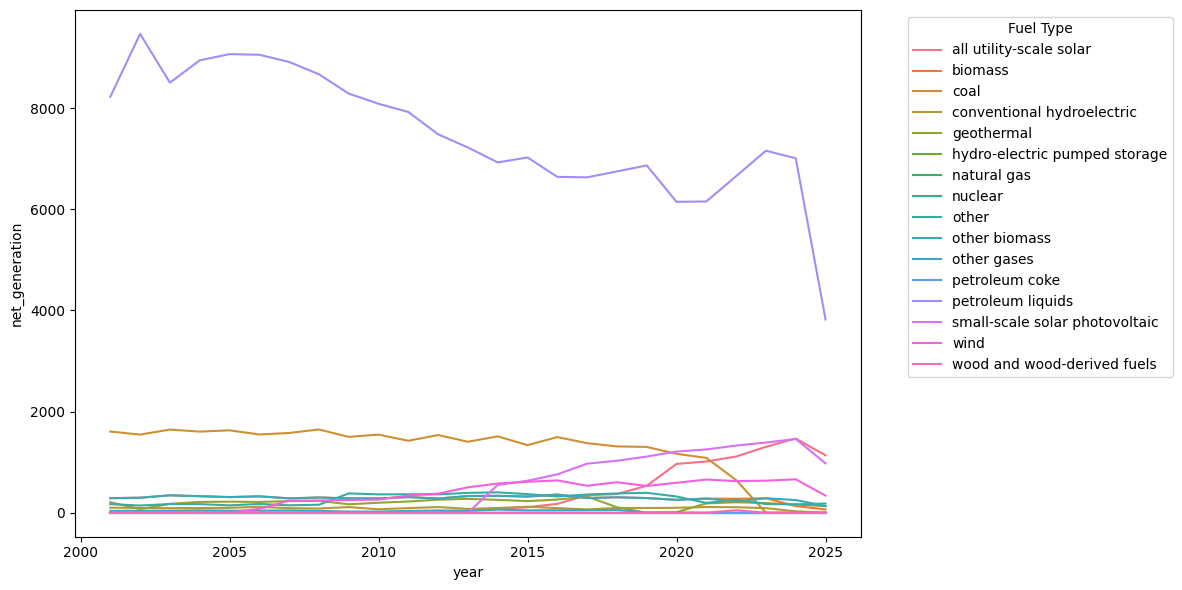

In [133]:
yearly_sum_unique = yearly_sum[~yearly_sum["fuel_type"].isin(["all fuels (utility-scale)", "all solar"])]

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum_unique, x="year", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

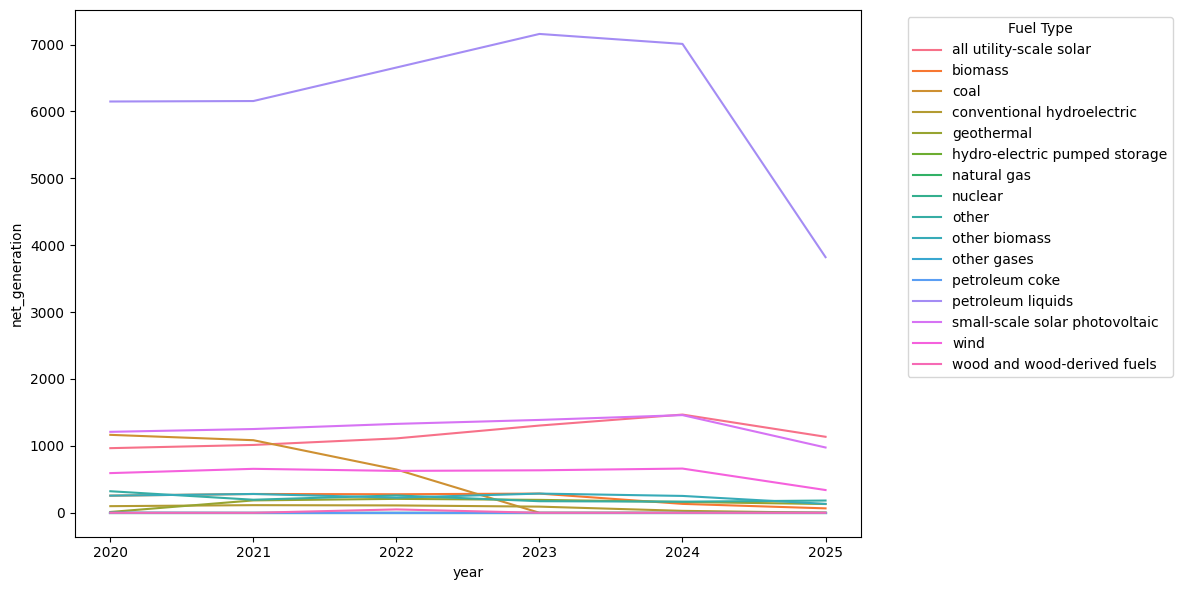

In [134]:
yearly_sum_unique_five = yearly_sum_unique[(yearly_sum_unique["year"] >= 2020) & (yearly_sum_unique["year"] <= 2025)]

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_sum_unique_five, x="year", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [135]:
# does not show much about trend, going to look monthly

monthly_sum_unique = tidy_df[~tidy_df["fuel_type"].isin(["all fuels (utility-scale)", "all solar"])]

monthly_unique_five = monthly_sum_unique[
    (monthly_sum_unique["year"] >= 2020) &
    (monthly_sum_unique["year"] <= 2025)
]

monthly_unique_five


,date,fuel_type,net_generation,year
4333,2020-01-01,coal,79.0,2020
4334,2020-01-01,petroleum liquids,572.0,2020
4335,2020-01-01,petroleum coke,NaN,2020
4336,2020-01-01,natural gas,NaN,2020
4337,2020-01-01,other gases,1.0,2020
...,...,...,...,...
5599,2025-07-01,other biomass,13.0,2025
5600,2025-07-01,hydro-electric pumped storage,NaN,2025
5601,2025-07-01,other,25.0,2025
5603,2025-07-01,small-scale solar photovoltaic,160.0,2025


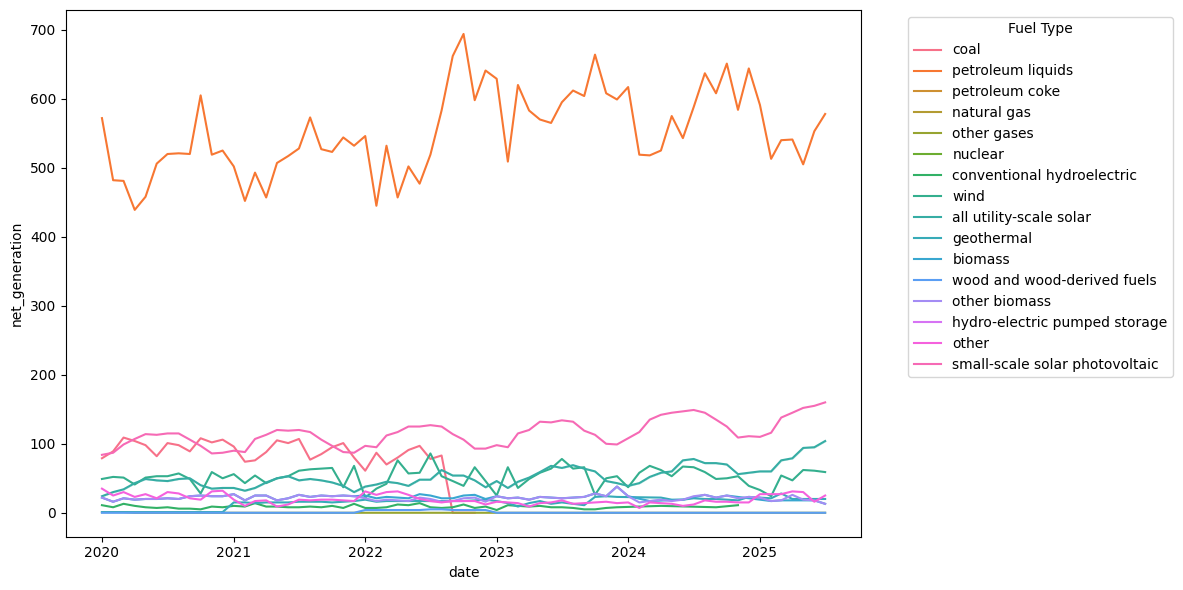

In [136]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=monthly_unique_five, x="date", y="net_generation", hue = "fuel_type")

plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()